# Problem 1d: Omitted Variable Bias Simulation

We simulate a known regression model and compare:

- the **correctly specified model**:  

$$
Y \sim X + Z
$$

- the **misspecified model**:  

$$
Y \sim X
$$

The goal is to show that if $Z$ is omitted and correlated with $X$, the estimated coefficient on $X$ becomes biased.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.precision", 6)

We use:

- `numpy` for simulation,
- `pandas` for tables,
- `statsmodels` for OLS estimation,
- `matplotlib` for graphs.

In [2]:
# Simulation settings
a = 1.0
b = 1.0
c = 1.0
rho = 0.6

n_small = 200
n_large = 10000
seed = 42

We define the true model as

$$
Y_i = a + bX_i + cZ_i + e_i
$$

with

$$
a = 1, \qquad b = 1, \qquad c = 1.
$$

So the true coefficient on $X_i$ is

$$
b = 1.
$$

We construct $Z_i$ to be correlated with $X_i$ using

$$
Z_i = \rho X_i + \sqrt{1-\rho^2}\,u_i,
\qquad \rho = 0.6.
$$

In [3]:
def run_simulation(n, seed, a, b, c, rho):
    rng = np.random.default_rng(seed)

    # Generate regressors and error term
    X = rng.normal(0, 1, n)
    u = rng.normal(0, 1, n)
    e = rng.normal(0, 1, n)

    # Build omitted variable correlated with X
    Z = rho * X + np.sqrt(1 - rho**2) * u

    # True model
    Y = a + b * X + c * Z + e

    # Store data
    df = pd.DataFrame({"Y": Y, "X": X, "Z": Z})

    # Full model: Y ~ X + Z
    X_full = sm.add_constant(df[["X", "Z"]])
    model_full = sm.OLS(df["Y"], X_full).fit()

    # Omitted model: Y ~ X
    X_omit = sm.add_constant(df[["X"]])
    model_omit = sm.OLS(df["Y"], X_omit).fit()

    return df, model_full, model_omit

The simulation follows

$$
X_i \sim N(0,1), \qquad
u_i \sim N(0,1), \qquad
e_i \sim N(0,1),
$$

and

$$
Z_i = \rho X_i + \sqrt{1-\rho^2}\,u_i.
$$

Then

$$
Y_i = a + bX_i + cZ_i + e_i.
$$

After generating the data, we estimate:

1. the **full model**

$$
Y_i = \alpha + \beta X_i + \gamma Z_i + \varepsilon_i
$$

2. the **omitted model**

$$
Y_i = \alpha + \beta X_i + u_i
$$

In [4]:
# Run simulations
df_small, model_full_small, model_omit_small = run_simulation(
    n=n_small, seed=seed, a=a, b=b, c=c, rho=rho
)

df_large, model_full_large, model_omit_large = run_simulation(
    n=n_large, seed=seed, a=a, b=b, c=c, rho=rho
)

We repeat the simulation for two sample sizes:

- $n = 200$
- $n = 10000$

This lets us test whether increasing the sample size removes omitted variable bias.

In [5]:
# Theoretical omitted-model coefficient on X
beta_omit_theory = b + c * rho

results = pd.DataFrame({
    "Quantity": [
        "True coefficient on X",
        "Theoretical omitted-model coefficient on X",
        "Estimated X coefficient (full model, n=200)",
        "Estimated X coefficient (omitted model, n=200)",
        "Estimated X coefficient (full model, n=10000)",
        "Estimated X coefficient (omitted model, n=10000)"
    ],
    "Value": [
        b,
        beta_omit_theory,
        model_full_small.params["X"],
        model_omit_small.params["X"],
        model_full_large.params["X"],
        model_omit_large.params["X"]
    ]
})

results

,Quantity,Value
0,True coefficient on X,1.000000
1,Theoretical omitted-model coefficient on X,1.600000
2,"Estimated X coefficient (full model, n=200)",0.925568
3,"Estimated X coefficient (omitted model, n=200)",1.481238
4,"Estimated X coefficient (full model, n=10000)",1.002342
5,"Estimated X coefficient (omitted model, n=10000)",1.583250


In this design, the omitted-model coefficient on $X_i$ is approximately

$$
\beta_{\text{omit}} \approx b + c\rho.
$$

Since

$$
b = 1, \qquad c = 1, \qquad \rho = 0.6,
$$

we expect

$$
\beta_{\text{omit}} \approx 1 + 1(0.6) = 1.6.
$$

So:

- the **full model** should estimate a coefficient close to $1$,
- the **omitted model** should estimate a coefficient close to $1.6$.

In [6]:
print("Small sample results (n=200)")
print("True coefficient on X:", b)
print("Full model estimate for X:", round(model_full_small.params["X"], 6))
print("Omitted model estimate for X:", round(model_omit_small.params["X"], 6))
print()

print("Large sample results (n=10000)")
print("True coefficient on X:", b)
print("Full model estimate for X:", round(model_full_large.params["X"], 6))
print("Omitted model estimate for X:", round(model_omit_large.params["X"], 6))
print()

print("Theoretical omitted-model coefficient on X:", round(beta_omit_theory, 6))

Small sample results (n=200)
True coefficient on X: 1.0
Full model estimate for X: 0.925568
Omitted model estimate for X: 1.481238

Large sample results (n=10000)
True coefficient on X: 1.0
Full model estimate for X: 1.002342
Omitted model estimate for X: 1.58325

Theoretical omitted-model coefficient on X: 1.6


The main comparison is between:

- the true coefficient $b$,
- the full-model estimate of $X$,
- the omitted-model estimate of $X$.

If the omitted-model estimate differs systematically from $b$, then the simulation confirms omitted variable bias.

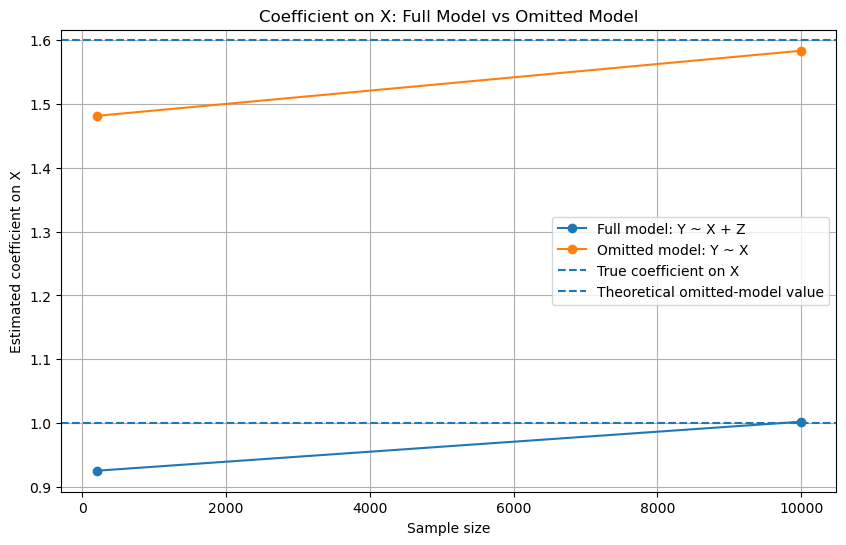

In [7]:
# Plot coefficient estimates
sample_sizes = [n_small, n_large]
full_estimates = [model_full_small.params["X"], model_full_large.params["X"]]
omit_estimates = [model_omit_small.params["X"], model_omit_large.params["X"]]

plt.plot(sample_sizes, full_estimates, marker="o", label="Full model: Y ~ X + Z")
plt.plot(sample_sizes, omit_estimates, marker="o", label="Omitted model: Y ~ X")
plt.axhline(y=b, linestyle="--", label="True coefficient on X")
plt.axhline(y=beta_omit_theory, linestyle="--", label="Theoretical omitted-model value")
plt.xlabel("Sample size")
plt.ylabel("Estimated coefficient on X")
plt.title("Coefficient on X: Full Model vs Omitted Model")
plt.legend()
plt.grid(True)
plt.show()

This graph shows that:

- the coefficient from the **full model** stays close to the true value,
- the coefficient from the **omitted model** stays above the true value,
- increasing the sample size makes the estimates more stable, but does **not** remove the bias.

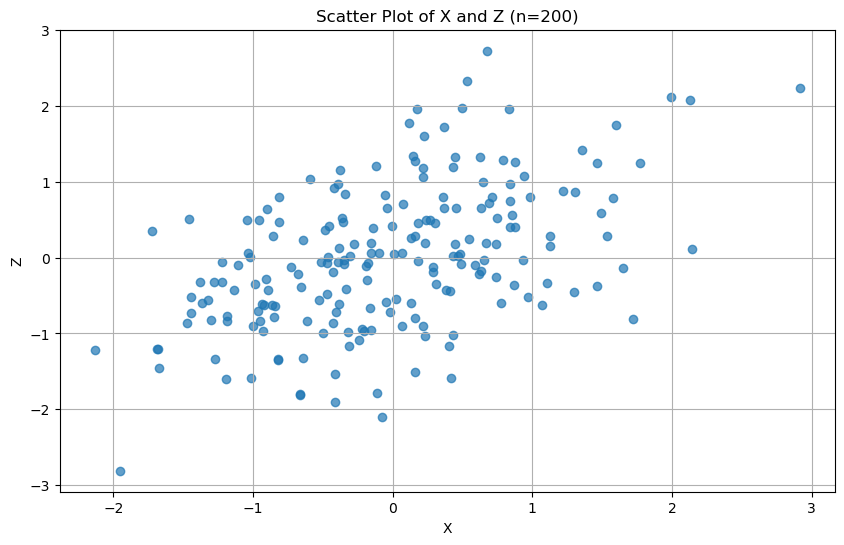

Sample correlation between X and Z (n=200): 0.5017


In [8]:
# Scatter plot to verify correlation between X and Z
plt.scatter(df_small["X"], df_small["Z"], alpha=0.7)
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Scatter Plot of X and Z (n=200)")
plt.grid(True)
plt.show()

print("Sample correlation between X and Z (n=200):",
      round(df_small[["X", "Z"]].corr().iloc[0, 1], 4))

This plot confirms that $X_i$ and $Z_i$ are positively correlated.

Omitted variable bias appears because:

1. $Z_i$ affects $Y_i$ since $c \neq 0$,
2. $Z_i$ is correlated with $X_i$ since $\operatorname{Corr}(X,Z) \neq 0$.

In [9]:
# Regression outputs for the small sample
print("=== Full model summary (n=200) ===")
print(model_full_small.summary())

print("\n=== Omitted model summary (n=200) ===")
print(model_omit_small.summary())

=== Full model summary (n=200) ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     231.5
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.93e-52
Time:                        11:58:54   Log-Likelihood:                -286.25
No. Observations:                 200   AIC:                             578.5
Df Residuals:                     197   BIC:                             588.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.

The regression summaries provide the full OLS results.

For this problem, the most important quantity is the estimated coefficient on $X_i$.

## Conclusion

We simulated the model

$$
Y_i = a + bX_i + cZ_i + e_i
$$

with $X_i$ and $Z_i$ positively correlated and $e_i$ independent of both.

We found that:

- the **full model** recovered the coefficient on $X_i$ close to its true value,
- the **omitted model** produced a biased coefficient on $X_i$,
- increasing the sample size did not remove the bias; it only reduced random variation.

Therefore, omitted variable bias is a specification problem, not a small-sample problem.